In [13]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('../data/usnd_cleaned.csv')

df = df.rename(columns={
    'individualsAndHouseholdsProgram': 'ihProgramDeclared',
    'publicAssistanceProgram': 'paProgramDeclared'
})

mapping = {'Yes': 1, 'No': 0}
df['ihProgramDeclared'] = df['ihProgramDeclared'].map(mapping)
df['paProgramDeclared'] = df['paProgramDeclared'].map(mapping)

df['ihProgramDeclared'] = df['ihProgramDeclared'].astype(int)
df['paProgramDeclared'] = df['paProgramDeclared'].astype(int)

print(df[['ihProgramDeclared', 'paProgramDeclared']].head())

required = ['incidentType', 'state', 'year', 'month', 'ihProgramDeclared', 'paProgramDeclared']
missing = [col for col in required if col not in df.columns]

if not missing:
    print(" All required columns from Milestones 1-4 are present.")
else:
    print(f" Missing columns: {missing}")

   ihProgramDeclared  paProgramDeclared
0                  0                  1
1                  0                  1
2                  0                  1
3                  0                  1
4                  0                  1
 All required columns from Milestones 1-4 are present.


In [15]:
# --- Milestone 4: Incident Type Aggregation ---
incident_distribution = df['incidentType'].value_counts().reset_index()
incident_distribution.columns = ['incidentType', 'declarationCount']

# Displaying top 10 for quick validation 
print(incident_distribution.head(10))

  incidentType  declarationCount
0        Storm             16250
1        Flood              9317
2    Hurricane              8764
3         Snow              3565
4         Fire              2647
5          Ice              1970
6      Tornado              1412
7      Drought              1292
8       Winter               301
9        Other               297


In [22]:
# 1. Treemap: Overall Disaster Composition
fig_treemap = px.treemap(incident_distribution, 
                         path=['incidentType'], 
                         values='declarationCount',
                         title='Milestone 4: US Natural Disaster Composition (Treemap)',
                         color='declarationCount',
                         color_continuous_scale='RdBu_r')
fig_treemap.show()

In [21]:
# 2. Bar Chart: Most Frequent Disaster Types
fig_bar = px.bar(incident_distribution.head(15), 
                 x='incidentType', 
                 y='declarationCount',
                 title='Top 15 Most Frequent Disaster Types',
                 labels={'declarationCount': 'Number of Declarations'},
                 color='declarationCount')
fig_bar.show()

Key Observations:

Most Frequent Types: Storms are the most recurring disaster type in the dataset with over 16,000 declarations, followed by Floods and Hurricanes.

Category Comparison: Atmospheric and water-based disasters (Storm, Flood, Hurricane) dominate the record. In contrast, geological events like Earthquakes and Volcanoes are statistically rare, representing a very small fraction of total declarations.

Disaster Composition: The Treemap reveals that the "Top 3" incident types account for more than 70% of all federal disaster activity, indicating that federal emergency management is primarily focused on weather-related events.

In [24]:
# State & Incident Grouping
# Calculate counts for every state and incident combination
state_incident_counts = df.groupby(['state', 'incidentType']).size().reset_index(name='count')

# Create a pivot table specifically for the Heatmap
heatmap_data = state_incident_counts.pivot(index='state', columns='incidentType', values='count').fillna(0)

# Displaying a sample of the counts
print(state_incident_counts.head())

  state incidentType  count
0    AK   Earthquake      7
1    AK         Fire     16
2    AK        Flood     46
3    AK        Other      4
4    AK         Snow      4


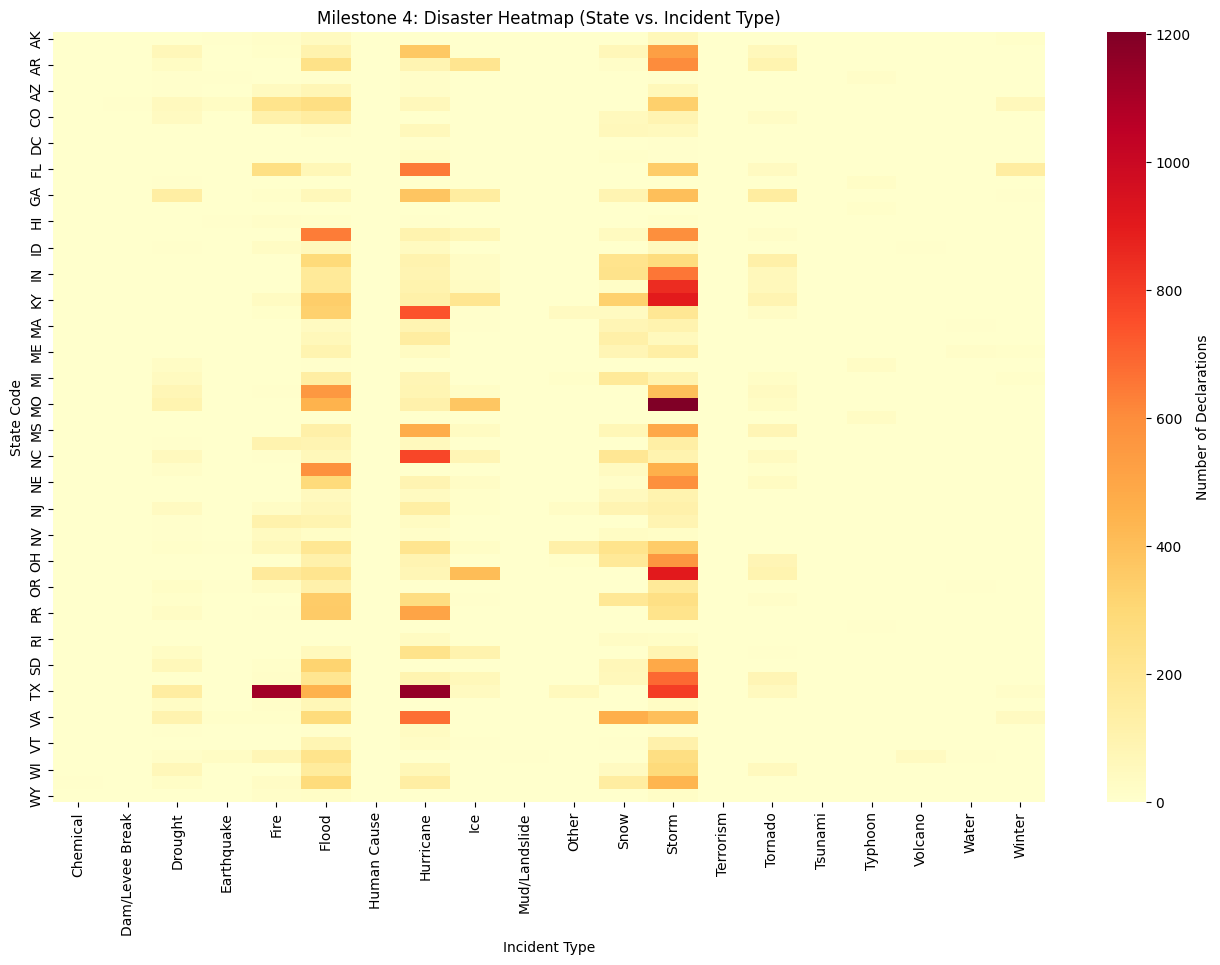

In [25]:
# 1. Heatmap: Incident Type vs State 
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, cbar_kws={'label': 'Number of Declarations'})
plt.title('Milestone 4: Disaster Heatmap (State vs. Incident Type)')
plt.xlabel('Incident Type')
plt.ylabel('State Code')
plt.show()

In [28]:
full_colors = {
    "Fire": "#FF4500",           # OrangeRed (Semantic)
    "Flood": "#1E90FF",          # DodgerBlue (Semantic)
    "Storm": "#708090",          # SlateGray
    "Hurricane": "#8B0000",      # DarkRed (High Impact)
    "Snow": "#F0F8FF",           # AliceBlue (Semantic)
    "Tornado": "#4B0082",        # Indigo
    "Drought": "#DAA520",        # GoldenRod (Dry/Yellow)
    "Earthquake": "#8B4513",     # SaddleBrown (Earth/Soil)
    "Ice": "#AFEEEE",            # PaleTurquoise
    "Winter": "#B0C4DE",         # LightSteelBlue
    "Coastal Storm": "#008B8B",  # DarkCyan
    "Severe Storm(s)": "#2F4F4F",# DarkSlateGray
    "Freezing": "#E0FFFF",       # LightCyan
    "Toxic Substances": "#32CD32",# LimeGreen (Warning)
    "Volcano": "#000000",        # Black (Ash)
    "Mudslide": "#A0522D",       # Sienna
    "Dam/Levee Break": "#4682B4",# SteelBlue
    "Terrorist": "#2F4F4F",      # DarkSlateGrey
    "Human Cause": "#696969",    # DimGray
    "Other": "#D3D3D3",          # LightGray
    "Chemical": "#ADFF2F",       # GreenYellow
    "Tsunami": "#00008B",        # DarkBlue
}

fig_stacked = px.bar(df_top10, 
                     x='state', 
                     y='count', 
                     color='incidentType', 
                     title='Incident Type Composition for Top 10 States',
                     labels={'count': 'Number of Declarations', 'state': 'State Code'},
                     color_discrete_map=full_colors, # Comprehensive map
                     category_orders={"incidentType": list(full_colors.keys())},
                     barmode='stack')

fig_stacked.show()

Key Observations:

State-Specific Trends: Large states like Texas (TX) and California (CA) show the highest density across multiple disaster types. Specifically, California shows a clear dominance in Fire declarations, while Florida and Louisiana are hotspots for Hurricanes.

Regional Dominance: The Heatmap reveals regional "signatures":

  Coastal Regions: Dominated by Hurricanes and Coastal Storms.

  Midwest/Plains: Show high frequency for Tornadoes and Severe Storms.

  Northern States: Highly concentrated in Snow and Ice incidents.

This geographic distribution explains why certain states require more frequent federal intervention than others.

In [29]:
#  Assistance Program Aggregation
# Group by incidentType and sum the activation counts 
assistance_analysis = df.groupby('incidentType')[['ihProgramDeclared', 'paProgramDeclared']].sum().reset_index()

assistance_analysis = assistance_analysis.rename(columns={
    'ihProgramDeclared': 'Individual Housing Assistance',
    'paProgramDeclared': 'Public Assistance Program'
})

print(assistance_analysis)

       incidentType  Individual Housing Assistance  Public Assistance Program
0          Chemical                              0                         17
1   Dam/Levee Break                              0                          6
2           Drought                              0                       1287
3        Earthquake                             29                         98
4              Fire                            431                       2498
5             Flood                            628                       9143
6       Human Cause                              0                          6
7         Hurricane                           2097                       8720
8               Ice                             16                       1960
9     Mud/Landslide                              4                         10
10            Other                              1                        296
11             Snow                              0              

In [32]:
# Total Assistance Bar Chart
assistance_analysis['Total Activations'] = (assistance_analysis['Individual Housing Assistance'] + 
                                            assistance_analysis['Public Assistance Program'])

fig_total_bar = px.bar(assistance_analysis, 
                       x='incidentType', 
                       y='Total Activations',
                       title='Total Federal Assistance Activations per Incident Type',
                       labels={'incidentType': 'Disaster Category', 'Total Activations': 'Total Program Counts'},
                       color='Total Activations',
                       color_continuous_scale='Viridis')

fig_total_bar.update_layout(xaxis={'categoryorder':'total descending'})
fig_total_bar.show()

In [31]:
assistance_melted = assistance_analysis.melt(id_vars='incidentType', 
                                            var_name='Program Type', 
                                            value_name='Activation Count')

# Create the Grouped Bar Chart
fig_assist = px.bar(assistance_melted, 
                    x='incidentType', 
                    y='Activation Count', 
                    color='Program Type',
                    barmode='group', # Required grouped format
                    title='FEMA Assistance Programs Activation by Incident Type',
                    labels={'incidentType': 'Disaster Category', 'Activation Count': 'Total Declarations'},
                    color_discrete_map={
                        'Individual Housing Assistance': '#FF6347', # Tomato Red
                        'Public Assistance Program': '#4682B4'      # Steel Blue
                    })

fig_assist.update_layout(xaxis={'categoryorder':'total descending'})
fig_assist.show()

Key Observations:

Assistance Frequency: Storms and Floods trigger federal assistance programs most often due to their high frequency. However, Hurricanes show the highest "intensity" of aid, often triggering both Individual and Public programs simultaneously.

Public vs. Individual Usage: There is a significant gap between program types. Public Assistance (PA) is activated far more frequently than Individual Housing (IH) assistance across nearly all categories.

Infrastructure Focus: This suggests that federal disaster response is heavily weighted toward infrastructure and community repair (PA) rather than direct financial aid to individuals (IH), particularly for events like Snow or localized Storms.

Final Conclusion:
Milestone 4 demonstrates that while disaster frequency is increasing (as seen in Milestone 2), the burden is not shared equally. Specific states act as disaster magnets for specific types of incidents. Furthermore, the federal response is structurally geared toward Public Assistance, which consistently outpaces Individual aid regardless of the disaster type. This analysis provides a complete view of the U.S. disaster landscape from 1953 to 2017.